# 08 - Direct Long-Horizon Feature Sweep (`M0-M3`) — 21.03.2026

This notebook is the **next direct-follow-up** after the `07` cumulative architecture sweep.

It freezes the architecture to the currently chosen family and uses the old `05` long-horizon logic as closely as possible:

- same **direct forecasting** setup,
- same **train/test split** ending at `2023-12-31 23:00`,
- same **`setA` temporal exports**,
- exact **`M0-M3`** temporal feature blocks from `05`,
- and a **cumulative-only long-horizon** target grid focused on the planning-relevant horizons.

The goal is no longer to tune architecture. The goal is to answer:

1. Does `M2` help once the architecture is frozen?
2. Does `M3` help more than `M2`?
3. Is `M1` basically redundant again, or does it matter more at the longer cumulative horizons?

The default run is intentionally a few-hour matrix rather than an all-day matrix.

In [1]:
# Section 0 - Fast runtime, feature, and smoke-fit sanity check
# This cell is intentionally quick. Run it first before starting the full sweep.

from __future__ import annotations

from pathlib import Path
import os
import sys
import platform
import time
import warnings
from typing import Dict, List, Tuple

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/codex-mplconfig')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR)
    absl.logging.set_stderrthreshold('error')
except Exception:
    pass

from IPython.display import Markdown, display

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

try:
    tf.get_logger().setLevel('ERROR')
except Exception:
    pass
warnings.filterwarnings('ignore', message='.*use_unbounded_threadpool.*')
warnings.filterwarnings('ignore', message='.*IProgress not found.*')
sns.set_theme(style='whitegrid')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

cwd = Path.cwd()
if cwd.name == 'thesis-project':
    PROJECT_ROOT = cwd
elif (cwd / 'thesis-project').exists():
    PROJECT_ROOT = cwd / 'thesis-project'
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / 'data'
FEATURE_DIR = DATA_DIR / 'features'
CLEAN_DIR = DATA_DIR / 'clean'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_METADATA_FILE = FEATURE_DIR / 'feature_metadata.csv'
PORTFOLIO_COVERAGE_FILE = FEATURE_DIR / 'portfolio_coverage.csv'
CAMPUS_PROXY_FILE = CLEAN_DIR / 'campus_building_features_for_models.csv'

RUN_BUILDINGS = ['U05', 'U06', 'LIB', 'U02B', 'SOC', 'U03']
RUN_MODES = ['M0', 'M1', 'M2', 'M3']
RUN_HORIZONS = [8, 10, 12, 16, 20, 24, 36]
TRAIN_END = pd.Timestamp('2023-12-31 23:00:00')
TEST_START = TRAIN_END + pd.Timedelta(hours=1)
FIT_VALIDATION_FRACTION = 0.10
BATCH_SIZE = 64
EPOCHS = 35
EARLY_STOPPING_PATIENCE = 6
LEARNING_RATE = 1e-3
SELECTED_ARCHITECTURE_ID = 'A6'  # Change to 'A3' if you want the simpler near-tied option.

LSTM_BASE_TEMPORAL_FEATURES = [
    'feat_heat_obs',
    'feat_outdoor_temp_c',
    'feat_wind_ms',
    'feat_solar_irradiance_wm2',
    'feat_hour_sin',
    'feat_hour_cos',
    'feat_dow_sin',
    'feat_dow_cos',
]

LSTM_WEATHER_MEMORY_FEATURES = [
    'feat_temp_roll24h',
]

LSTM_SYSTEM_DYNAMIC_FEATURES = [
    'feat_space_heat_active',
    'feat_space_deltaT_c',
    'feat_space_low_deltaT_flag',
    'feat_vent_heat_active',
    'feat_vent_deltaT_c',
    'feat_vent_low_deltaT_flag',
]

MODE_FEATURES = {
    'M0': LSTM_BASE_TEMPORAL_FEATURES.copy(),
    'M1': LSTM_BASE_TEMPORAL_FEATURES + LSTM_WEATHER_MEMORY_FEATURES,
    'M2': LSTM_BASE_TEMPORAL_FEATURES + LSTM_SYSTEM_DYNAMIC_FEATURES,
    'M3': LSTM_BASE_TEMPORAL_FEATURES + LSTM_SYSTEM_DYNAMIC_FEATURES + LSTM_WEATHER_MEMORY_FEATURES,
}
for mode, cols in MODE_FEATURES.items():
    seen = set()
    MODE_FEATURES[mode] = [c for c in cols if not (c in seen or seen.add(c))]

ARCHITECTURES = {
    'A3': {
        'architecture_id': 'A3',
        'architecture_label': 'single 64 | L48',
        'lookback_hours': 48,
        'lstm_stack': [64],
        'dropout': 0.0,
        'dense_units': 16,
        'notes': 'Lean single-layer near-tied option from 07.',
    },
    'A6': {
        'architecture_id': 'A6',
        'architecture_label': 'single 64 | L72',
        'lookback_hours': 72,
        'lstm_stack': [64],
        'dropout': 0.0,
        'dense_units': 16,
        'notes': 'Best overall long-horizon planning architecture from 07.',
    },
}
SELECTED_ARCHITECTURE = ARCHITECTURES[SELECTED_ARCHITECTURE_ID]
TOTAL_FITS = len(RUN_BUILDINGS) * len(RUN_MODES) * len(RUN_HORIZONS)

runtime_rows = [
    {'check_name': 'python_executable', 'value': sys.executable, 'status': 'INFO'},
    {'check_name': 'python_architecture', 'value': platform.machine(), 'status': 'PASS' if platform.machine() == 'arm64' else 'WARN'},
    {'check_name': 'tensorflow_version', 'value': tf.__version__, 'status': 'INFO'},
    {'check_name': 'tensorflow_devices', 'value': str(tf.config.list_physical_devices()), 'status': 'INFO'},
    {'check_name': 'gpu_visible_to_tensorflow', 'value': str(tf.config.list_physical_devices('GPU')), 'status': 'PASS' if tf.config.list_physical_devices('GPU') else 'WARN'},
    {'check_name': 'selected_architecture', 'value': SELECTED_ARCHITECTURE_ID, 'status': 'INFO'},
    {'check_name': 'total_planned_fits', 'value': str(TOTAL_FITS), 'status': 'INFO'},
]
runtime_check_df = pd.DataFrame(runtime_rows)
display(runtime_check_df)


def set_all_seeds(seed: int) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def add_cumulative_targets(df: pd.DataFrame, horizons: List[int]) -> pd.DataFrame:
    out = df.copy()
    heat = out['heat_kwh'].astype(float)
    for horizon in horizons:
        out[f'target_cum_h{horizon}'] = sum(heat.shift(-i) for i in range(horizon))
    return out


def build_sequences(
    df_scaled: pd.DataFrame,
    dynamic_cols: List[str],
    target_col: str,
    split_mask: np.ndarray,
    lookback: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    X_list, y_list, ts_list = [], [], []
    mask = np.asarray(split_mask, dtype=bool)
    for end_idx in range(lookback, len(df_scaled)):
        if not mask[end_idx]:
            continue
        start_idx = end_idx - lookback
        if not mask[start_idx:end_idx].all():
            continue
        window = df_scaled.iloc[start_idx:end_idx]
        target_val = df_scaled.iloc[end_idx][target_col]
        if window[dynamic_cols].isna().any().any() or pd.isna(target_val):
            continue
        X_list.append(window[dynamic_cols].values.astype('float32'))
        y_list.append(float(target_val))
        ts_list.append(pd.Timestamp(df_scaled.iloc[end_idx]['datetime']))
    if not X_list:
        return (
            np.empty((0, lookback, len(dynamic_cols)), dtype='float32'),
            np.empty((0,), dtype='float32'),
            np.empty((0,), dtype='datetime64[ns]'),
        )
    return (
        np.stack(X_list, axis=0),
        np.array(y_list, dtype='float32'),
        np.array(ts_list, dtype='datetime64[ns]'),
    )


def make_optimizer(learning_rate: float):
    try:
        return tf.keras.optimizers.legacy.Adam(learning_rate=learning_rate)
    except Exception:
        return keras.optimizers.Adam(learning_rate=learning_rate)


def build_lstm_from_spec(n_timesteps: int, n_features: int, spec: Dict, learning_rate: float) -> keras.Model:
    temporal_in = keras.Input(shape=(n_timesteps, n_features), name='temporal_input')
    x = temporal_in
    stack = spec['lstm_stack']
    for layer_idx, units in enumerate(stack, start=1):
        return_sequences = layer_idx < len(stack)
        x = layers.LSTM(units, return_sequences=return_sequences, name=f'lstm_{layer_idx}')(x)
        if return_sequences and spec['dropout'] > 0:
            x = layers.Dropout(spec['dropout'], name=f'dropout_{layer_idx}')(x)
    x = layers.Dense(spec['dense_units'], activation='relu', name='dense_1')(x)
    out = layers.Dense(1, name='output')(x)
    model = keras.Model(inputs=temporal_in, outputs=out, name=spec['architecture_id'])
    model.compile(optimizer=make_optimizer(learning_rate), loss='mse', metrics=['mse'])
    return model


feature_meta = pd.read_csv(FEATURE_METADATA_FILE)
feature_paths = feature_meta.set_index('building')['path_setA'].to_dict()

quick_ok = True
quick_messages = []
try:
    sanity_building = 'U06'
    sanity_horizon = 24
    sanity_target = f'target_cum_h{sanity_horizon}'
    sanity_mode = 'M3'
    sanity_arch = SELECTED_ARCHITECTURE
    sanity_path = PROJECT_ROOT / feature_paths[sanity_building]
    if not sanity_path.exists():
        raise FileNotFoundError(sanity_path)

    sanity_df = pd.read_csv(sanity_path, parse_dates=['datetime']).sort_values('datetime').reset_index(drop=True)
    sanity_df = add_cumulative_targets(sanity_df, [sanity_horizon])

    required_cols = sorted(set(sum((MODE_FEATURES[m] for m in RUN_MODES), []) + ['heat_kwh', sanity_target]) - set(sanity_df.columns))
    if required_cols:
        raise ValueError(f'Missing required columns for M0-M3: {required_cols}')

    dt = pd.to_datetime(sanity_df['datetime'])
    feature_train_mask = dt <= TRAIN_END
    target_train_mask = dt <= TRAIN_END - pd.Timedelta(hours=sanity_horizon - 1)
    test_mask = dt >= TEST_START

    scaler_X = StandardScaler().fit(sanity_df.loc[feature_train_mask, MODE_FEATURES[sanity_mode]].values)
    scaler_y = StandardScaler().fit(sanity_df.loc[target_train_mask, [sanity_target]].dropna().values)

    sanity_scaled = sanity_df.copy()
    sanity_scaled[MODE_FEATURES[sanity_mode]] = scaler_X.transform(sanity_scaled[MODE_FEATURES[sanity_mode]].values)
    sanity_scaled[f'{sanity_target}_scaled'] = np.nan
    nonnull = sanity_scaled[sanity_target].notna()
    sanity_scaled.loc[nonnull, f'{sanity_target}_scaled'] = scaler_y.transform(sanity_scaled.loc[nonnull, [sanity_target]].values).reshape(-1)

    X_train_full, y_train_full, _ = build_sequences(
        sanity_scaled,
        MODE_FEATURES[sanity_mode],
        f'{sanity_target}_scaled',
        target_train_mask.values,
        sanity_arch['lookback_hours'],
    )
    X_test, y_test, _ = build_sequences(
        sanity_scaled,
        MODE_FEATURES[sanity_mode],
        f'{sanity_target}_scaled',
        test_mask.values,
        sanity_arch['lookback_hours'],
    )

    if X_train_full.shape[0] < 64 or X_test.shape[0] < 32:
        raise ValueError('Not enough sequences for a meaningful smoke fit.')

    n_val = min(128, max(32, int(round(X_train_full.shape[0] * 0.10))))
    n_val = min(n_val, X_train_full.shape[0] - 1)
    split_at = X_train_full.shape[0] - n_val
    X_train = X_train_full[:split_at][:512]
    y_train = y_train_full[:split_at][:512]
    X_val = X_train_full[split_at:][:128]
    y_val = y_train_full[split_at:][:128]

    set_all_seeds(SEED)
    tf.keras.backend.clear_session()
    smoke_model = build_lstm_from_spec(sanity_arch['lookback_hours'], len(MODE_FEATURES[sanity_mode]), sanity_arch, LEARNING_RATE)
    smoke_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=1,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    y_pred_scaled = smoke_model.predict(X_val[:64], verbose=0).reshape(-1, 1)
    y_true = scaler_y.inverse_transform(y_val[:64].reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
    smoke_rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    quick_messages.append(
        f'Smoke fit PASS on {sanity_building}, {sanity_target}, {sanity_mode}, {sanity_arch["architecture_id"]}: '
        f'train_seq={X_train_full.shape[0]}, test_seq={X_test.shape[0]}, 1-epoch val RMSE={smoke_rmse:.2f}'
    )
except Exception as exc:
    quick_ok = False
    quick_messages.append(f'Smoke fit failed: {type(exc).__name__}: {exc}')

status_text = 'PASS' if quick_ok else 'WARN'
display(Markdown(f"""
### Fast sanity check

- **Status:** `{status_text}`
- **Interpretation:** this quick check verifies the runtime, the exact `05` `M0-M3` feature blocks, the cumulative target construction, the split logic, and one tiny fit using the frozen architecture.
- **Next step if PASS:** start the main run in Section 4a.
- **Next step if WARN:** do **not** start the sweep before fixing the issue below.

{'<br>'.join('- ' + msg for msg in quick_messages)}
"""))

/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,check_name,value,status
0,python_executable,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,INFO
1,python_architecture,arm64,PASS
2,tensorflow_version,2.19.1,INFO
3,tensorflow_devices,"[PhysicalDevice(name='/physical_device:CPU:0',...",INFO
4,gpu_visible_to_tensorflow,"[PhysicalDevice(name='/physical_device:GPU:0',...",PASS
5,selected_architecture,A6,INFO
6,total_planned_fits,168,INFO


I0000 00:00:1774080080.411099 1116801 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1774080080.411327 1116801 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



### Fast sanity check

- **Status:** `PASS`
- **Interpretation:** this quick check verifies the runtime, the exact `05` `M0-M3` feature blocks, the cumulative target construction, the split logic, and one tiny fit using the frozen architecture.
- **Next step if PASS:** start the main run in Section 4a.
- **Next step if WARN:** do **not** start the sweep before fixing the issue below.

- Smoke fit PASS on U06, target_cum_h24, M3, A6: train_seq=14259, test_seq=7607, 1-epoch val RMSE=642.73


## Section 1 - Experiment design

This notebook deliberately **freezes the architecture** and moves the question to feature utility.

Default setup:

- architecture: **`A6 = single 64 | L72`**
- buildings: `U05, U06, LIB, U02B, SOC, U03`
- modes: **`M0-M3`**
- cumulative horizons: **`8, 10, 12, 16, 20, 24, 36`**
- seed: `42`
- split: same direct split logic as `05`

Why this design:

- `07` already showed that the main architecture question is mostly settled,
- short cumulative horizons (`1h`, `4h`) were not the strongest LSTM regime,
- and if the richer temporal blocks help anywhere, they should help most at the longer planning horizons.

In [2]:
# Section 1a - Metadata, target specs, mode table, and frozen architecture

feature_meta = pd.read_csv(FEATURE_METADATA_FILE)
portfolio_cov = pd.read_csv(PORTFOLIO_COVERAGE_FILE, parse_dates=['first_obs', 'last_obs'])
proxy_df = pd.read_csv(CAMPUS_PROXY_FILE)
feature_paths = feature_meta.set_index('building')['path_setA'].to_dict()

missing_buildings = [b for b in RUN_BUILDINGS if b not in feature_paths]
if missing_buildings:
    raise ValueError(f'Missing feature metadata for buildings: {missing_buildings}')

TARGET_SPECS = [
    {
        'target_name': f'target_cum_h{h}',
        'target_family': 'cumulative',
        'horizon_hours': int(h),
    }
    for h in RUN_HORIZONS
]

target_specs_df = pd.DataFrame(TARGET_SPECS)
mode_catalog_df = pd.DataFrame([
    {'mode': mode, 'n_features': len(cols), 'feature_list': ', '.join(cols)}
    for mode, cols in MODE_FEATURES.items()
])
selected_architecture_df = pd.DataFrame([SELECTED_ARCHITECTURE])

RUNLOG_FILE = RESULTS_DIR / 'direct_long_horizon_feature_sweep_run_log_21032026.csv'
CHECKPOINT_FILE = RESULTS_DIR / 'direct_long_horizon_feature_sweep_checkpoint_21032026.csv'
COVERAGE_FILE = RESULTS_DIR / 'direct_long_horizon_feature_sweep_coverage_21032026.csv'
SUMMARY_FILE = RESULTS_DIR / 'direct_long_horizon_feature_sweep_summary_21032026.csv'
MODE_OVERALL_FILE = RESULTS_DIR / 'direct_long_horizon_feature_sweep_mode_overall_21032026.csv'
GAIN_FILE = RESULTS_DIR / 'direct_long_horizon_feature_sweep_gain_vs_M0_21032026.csv'

print('Buildings             :', RUN_BUILDINGS)
print('Modes                 :', RUN_MODES)
print('Horizons              :', RUN_HORIZONS)
print('Selected architecture :', SELECTED_ARCHITECTURE_ID, '-', SELECTED_ARCHITECTURE['architecture_label'])
print('Total fits            :', len(RUN_BUILDINGS) * len(RUN_MODES) * len(TARGET_SPECS))

display(target_specs_df)
display(mode_catalog_df)
display(selected_architecture_df[['architecture_id', 'architecture_label', 'lookback_hours', 'lstm_stack', 'dropout', 'dense_units', 'notes']])

Buildings             : ['U05', 'U06', 'LIB', 'U02B', 'SOC', 'U03']
Modes                 : ['M0', 'M1', 'M2', 'M3']
Horizons              : [8, 10, 12, 16, 20, 24, 36]
Selected architecture : A6 - single 64 | L72
Total fits            : 168


,target_name,target_family,horizon_hours
0,target_cum_h8,cumulative,8
1,target_cum_h10,cumulative,10
2,target_cum_h12,cumulative,12
3,target_cum_h16,cumulative,16
4,target_cum_h20,cumulative,20
5,target_cum_h24,cumulative,24
6,target_cum_h36,cumulative,36


,mode,n_features,feature_list
0,M0,8,"feat_heat_obs, feat_outdoor_temp_c, feat_wind_..."
1,M1,9,"feat_heat_obs, feat_outdoor_temp_c, feat_wind_..."
2,M2,14,"feat_heat_obs, feat_outdoor_temp_c, feat_wind_..."
3,M3,15,"feat_heat_obs, feat_outdoor_temp_c, feat_wind_..."


,architecture_id,architecture_label,lookback_hours,lstm_stack,dropout,dense_units,notes
0,A6,single 64 | L72,72,[64],0.0,16,Best overall long-horizon planning architectur...


In [3]:
# Section 2 - Load setA feature frames, build cumulative targets, and define 05-compatible splits


def load_feature_frame(path_str: str) -> pd.DataFrame:
    csv_path = PROJECT_ROOT / path_str
    if not csv_path.exists():
        raise FileNotFoundError(csv_path)
    return pd.read_csv(csv_path, parse_dates=['datetime']).sort_values('datetime').reset_index(drop=True)


features_by_building: Dict[str, pd.DataFrame] = {}
split_masks: Dict[str, Dict[str, Dict[str, np.ndarray]]] = {}
coverage_rows = []
all_required_temporal = sorted(set(sum((MODE_FEATURES[m] for m in RUN_MODES), [])))

for bldg in RUN_BUILDINGS:
    df = load_feature_frame(feature_paths[bldg])
    df = add_cumulative_targets(df, RUN_HORIZONS)

    missing_cols = sorted(set(all_required_temporal + ['heat_kwh']) - set(df.columns))
    if missing_cols:
        raise ValueError(f'{bldg} is missing required columns: {missing_cols}')

    dt = pd.to_datetime(df['datetime'])
    base_test_mask = dt >= TEST_START
    feature_train_mask = dt <= TRAIN_END

    features_by_building[bldg] = df
    split_masks[bldg] = {}

    row = {
        'building': bldg,
        'rows_total': int(len(df)),
        'rows_feature_train': int(feature_train_mask.sum()),
        'rows_test_base': int(base_test_mask.sum()),
        'datetime_start': dt.min(),
        'datetime_end': dt.max(),
    }
    for spec in TARGET_SPECS:
        target_name = spec['target_name']
        horizon_hours = int(spec['horizon_hours'])
        train_issue_end = TRAIN_END - pd.Timedelta(hours=horizon_hours - 1)
        train_mask = dt <= train_issue_end
        split_masks[bldg][target_name] = {
            'train': train_mask.values,
            'test': base_test_mask.values,
            'feature_train': feature_train_mask.values,
            'train_issue_end': train_issue_end,
        }
        row[f'{target_name}_issue_train_rows'] = int(train_mask.sum())
        row[f'{target_name}_nonnull_train'] = int(df.loc[train_mask, target_name].notna().sum())
        row[f'{target_name}_nonnull_test'] = int(df.loc[base_test_mask, target_name].notna().sum())
    coverage_rows.append(row)

coverage_df = pd.DataFrame(coverage_rows).sort_values('building').reset_index(drop=True)
coverage_df.to_csv(COVERAGE_FILE, index=False)
display(coverage_df)
print(f'Saved coverage table to {COVERAGE_FILE}')

display(Markdown(f"""
### Split note

This keeps the `05` direct logic:

- feature scalers use rows up to **`{TRAIN_END}`**,
- each cumulative target truncates the last valid train issue time to **`TRAIN_END - (H-1)` hours**,
- test rows begin at **`{TEST_START}`**.
"""))

,building,rows_total,rows_feature_train,rows_test_base,datetime_start,datetime_end,target_cum_h8_issue_train_rows,target_cum_h8_nonnull_train,target_cum_h8_nonnull_test,target_cum_h10_issue_train_rows,...,target_cum_h16_nonnull_test,target_cum_h20_issue_train_rows,target_cum_h20_nonnull_train,target_cum_h20_nonnull_test,target_cum_h24_issue_train_rows,target_cum_h24_nonnull_train,target_cum_h24_nonnull_test,target_cum_h36_issue_train_rows,target_cum_h36_nonnull_train,target_cum_h36_nonnull_test
0,LIB,22954,14170,8784,2022-05-20 14:00:00,2024-12-31 23:00:00,14163,14163,8777,14161,...,8769,14151,14151,8765,14147,14147,8761,14135,14135,8749
1,SOC,22954,14170,8784,2022-05-20 14:00:00,2024-12-31 23:00:00,14163,14163,8777,14161,...,8769,14151,14151,8765,14147,14147,8761,14135,14135,8749
2,U02B,22925,14170,8755,2022-05-20 14:00:00,2024-12-30 18:00:00,14163,14163,8748,14161,...,8740,14151,14151,8736,14147,14147,8732,14135,14135,8720
3,U03,22925,14170,8755,2022-05-20 14:00:00,2024-12-30 18:00:00,14163,14163,8748,14161,...,8740,14151,14151,8736,14147,14147,8732,14135,14135,8720
4,U05,25206,16451,8755,2022-02-14 13:00:00,2024-12-30 18:00:00,16444,16444,8748,16442,...,8740,16432,16432,8736,16428,16428,8732,16416,16416,8720
5,U06,25206,16451,8755,2022-02-14 13:00:00,2024-12-30 18:00:00,16444,16444,8748,16442,...,8740,16432,16432,8736,16428,16428,8732,16416,16416,8720


Saved coverage table to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_coverage_21032026.csv



### Split note

This keeps the `05` direct logic:

- feature scalers use rows up to **`2023-12-31 23:00:00`**,
- each cumulative target truncates the last valid train issue time to **`TRAIN_END - (H-1)` hours**,
- test rows begin at **`2024-01-01 00:00:00`**.


In [4]:
# Section 3 - Scalers and run helpers


temporal_scalers: Dict[str, StandardScaler] = {}
target_scalers: Dict[Tuple[str, str], StandardScaler] = {}

for bldg, df in features_by_building.items():
    feature_train_mask = split_masks[bldg][TARGET_SPECS[0]['target_name']]['feature_train']

    scaler_X = StandardScaler()
    scaler_X.fit(df.loc[feature_train_mask, all_required_temporal].values)
    temporal_scalers[bldg] = scaler_X

    for spec in TARGET_SPECS:
        target_name = spec['target_name']
        target_train_mask = split_masks[bldg][target_name]['train']
        y_train = df.loc[target_train_mask, [target_name]].dropna().values
        if len(y_train) == 0:
            continue
        scaler_y = StandardScaler()
        scaler_y.fit(y_train)
        target_scalers[(bldg, target_name)] = scaler_y


def make_internal_fit_split(X: np.ndarray, y: np.ndarray, frac: float):
    n = X.shape[0]
    if n == 0:
        return X, y, X, y
    if frac <= 0 or n < 50:
        return X, y, np.empty((0,) + X.shape[1:], dtype=X.dtype), np.empty((0,), dtype=y.dtype)
    n_val = max(1, int(round(n * frac)))
    n_val = min(n_val, max(1, n - 1))
    split_at = n - n_val
    return X[:split_at], y[:split_at], X[split_at:], y[split_at:]


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    denom = float(np.sum(np.abs(y_true)))
    wape = float(100.0 * np.sum(np.abs(y_true - y_pred)) / denom) if denom > 0 else np.nan
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'wape_pct': wape}


def prepare_scaled_frame(df: pd.DataFrame, building: str, target_name: str) -> pd.DataFrame:
    out = df.copy()
    out[all_required_temporal] = temporal_scalers[building].transform(out[all_required_temporal].values)
    scaler_y = target_scalers[(building, target_name)]
    nonnull = out[target_name].notna()
    out[f'{target_name}_scaled'] = np.nan
    out.loc[nonnull, f'{target_name}_scaled'] = scaler_y.transform(out.loc[nonnull, [target_name]].values).reshape(-1)
    return out


def persistence_baseline_prediction(last_heat: np.ndarray, horizon_hours: int) -> np.ndarray:
    return horizon_hours * last_heat


def run_one_case(building: str, target_spec: Dict, mode: str, epochs: int | None = None) -> Dict:
    set_all_seeds(SEED)
    tf.keras.backend.clear_session()

    arch = SELECTED_ARCHITECTURE
    target_name = target_spec['target_name']
    horizon_hours = int(target_spec['horizon_hours'])
    dynamic_cols = MODE_FEATURES[mode].copy()

    df = features_by_building[building].copy()
    masks = split_masks[building][target_name]
    df_scaled = prepare_scaled_frame(df, building, target_name)
    target_scaled_col = f'{target_name}_scaled'

    X_train_full, y_train_full, _ = build_sequences(df_scaled, dynamic_cols, target_scaled_col, masks['train'], arch['lookback_hours'])
    X_test, y_test, ts_test = build_sequences(df_scaled, dynamic_cols, target_scaled_col, masks['test'], arch['lookback_hours'])
    X_train, y_train, X_fit_val, y_fit_val = make_internal_fit_split(X_train_full, y_train_full, FIT_VALIDATION_FRACTION)

    row = {
        'building': building,
        'mode': mode,
        'seed': SEED,
        'target_name': target_name,
        'target_family': target_spec['target_family'],
        'horizon_hours': horizon_hours,
        'architecture_id': arch['architecture_id'],
        'architecture_label': arch['architecture_label'],
        'lookback_hours': int(arch['lookback_hours']),
        'lstm_stack': ' -> '.join(str(u) for u in arch['lstm_stack']),
        'dropout': float(arch['dropout']),
        'dense_units': int(arch['dense_units']),
        'n_dynamic_features': len(dynamic_cols),
        'n_train_seq': int(X_train_full.shape[0]),
        'n_fit_val_seq': int(X_fit_val.shape[0]),
        'n_test_seq': int(X_test.shape[0]),
        'train_issue_end': str(masks['train_issue_end']),
        'status': 'ok',
        'notes': arch['notes'],
    }

    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        row.update({'status': 'skipped_insufficient_sequences'})
        for key in ['rmse', 'mae', 'r2', 'wape_pct', 'baseline_wape_pct', 'delta_wape_vs_baseline', 'best_epoch', 'history_epochs_ran']:
            row[key] = np.nan
        return row

    model = build_lstm_from_spec(arch['lookback_hours'], len(dynamic_cols), arch, LEARNING_RATE)
    callbacks = []
    validation_data = None
    if X_fit_val.shape[0] > 0:
        validation_data = (X_fit_val, y_fit_val)
        callbacks = [
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0),
        ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=validation_data,
        epochs=epochs or EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=callbacks,
    )

    scaler_y = target_scalers[(building, target_name)]
    y_pred_scaled = model.predict(X_test, verbose=0).reshape(-1, 1)
    y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    metrics = compute_metrics(y_true, y_pred)

    test_df = df.iloc[-len(ts_test):].copy() if len(ts_test) > 0 else df.iloc[0:0].copy()
    if len(ts_test) > 0:
        test_df = df[df['datetime'].isin(pd.to_datetime(ts_test))].copy().sort_values('datetime').reset_index(drop=True)
    baseline_pred = persistence_baseline_prediction(test_df['heat_kwh'].astype(float).values, horizon_hours)
    baseline_metrics = compute_metrics(y_true, baseline_pred)

    row.update(metrics)
    row['baseline_wape_pct'] = baseline_metrics['wape_pct']
    row['delta_wape_vs_baseline'] = row['wape_pct'] - row['baseline_wape_pct']

    train_losses = history.history.get('loss', [])
    val_losses = history.history.get('val_loss', [])
    row['history_epochs_ran'] = len(train_losses)
    if val_losses:
        row['best_epoch'] = int(np.argmin(val_losses) + 1)
    else:
        row['best_epoch'] = int(np.argmin(train_losses) + 1) if train_losses else np.nan

    return row

## Section 4 - Main run

Default matrix:

- buildings: `6`
- modes: `4`
- cumulative horizons: `7`
- architecture: `1` frozen choice
- seed: `1`

Total fits: `168`

This should be a practical few-hour run on the GPU-enabled environment. The loop checkpoint-saves after every fit, so it can be resumed.

In [5]:
# Section 4a - Execute the direct long-horizon feature sweep with checkpoint resume

RUN_SWEEP_NOW = True
RESUME_FROM_CHECKPOINT = True


def finalize_run_log(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    out['_building_rank'] = out['building'].map({b: i for i, b in enumerate(RUN_BUILDINGS)}).fillna(999).astype(int)
    out['_horizon_rank'] = out['horizon_hours'].fillna(999).astype(int)
    out['_mode_rank'] = out['mode'].map({m: i for i, m in enumerate(RUN_MODES)}).fillna(999).astype(int)
    out = out.sort_values(['_building_rank', '_horizon_rank', '_mode_rank']).drop(columns=['_building_rank', '_horizon_rank', '_mode_rank']).reset_index(drop=True)
    return out


def run_log_matches_current_schema(df: pd.DataFrame) -> bool:
    required_cols = {
        'building', 'mode', 'target_name', 'horizon_hours', 'architecture_id',
        'wape_pct', 'baseline_wape_pct', 'delta_wape_vs_baseline', 'status', 'train_issue_end'
    }
    current_targets = {t['target_name'] for t in TARGET_SPECS}
    current_modes = set(RUN_MODES)
    if df is None or df.empty:
        return False
    if not required_cols.issubset(set(df.columns)):
        return False
    if not set(df['target_name'].dropna().unique()).issubset(current_targets):
        return False
    if not set(df['mode'].dropna().unique()).issubset(current_modes):
        return False
    if 'architecture_id' in df.columns and not set(df['architecture_id'].dropna().unique()).issubset({SELECTED_ARCHITECTURE_ID}):
        return False
    return True


def format_seconds(seconds: float) -> str:
    seconds = max(0, int(round(seconds)))
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours > 0:
        return f'{hours:02d}:{minutes:02d}:{secs:02d}'
    return f'{minutes:02d}:{secs:02d}'


rows = []
completed_keys = set()
if RESUME_FROM_CHECKPOINT and CHECKPOINT_FILE.exists():
    candidate_df = pd.read_csv(CHECKPOINT_FILE)
    if run_log_matches_current_schema(candidate_df):
        rows = candidate_df.to_dict('records')
        ok_df = candidate_df.loc[candidate_df['status'] == 'ok'].copy()
        completed_keys = set(zip(ok_df['building'], ok_df['target_name'], ok_df['mode']))
        print(f'Resuming from checkpoint: {len(completed_keys)} completed fits found.')


total_fits = len(RUN_BUILDINGS) * len(TARGET_SPECS) * len(RUN_MODES)
completed = len(completed_keys)
start_time = time.time()

if RUN_SWEEP_NOW:
    iterator = []
    for bldg in RUN_BUILDINGS:
        for spec in TARGET_SPECS:
            for mode in RUN_MODES:
                iterator.append((bldg, spec, mode))

    progress = tqdm(iterator, desc='direct_long_feature_sweep', total=total_fits) if tqdm is not None else iterator

    for item in progress:
        bldg, spec, mode = item
        fit_key = (bldg, spec['target_name'], mode)
        if fit_key in completed_keys:
            if tqdm is not None:
                progress.set_postfix_str(f'{bldg} {spec["target_name"]} {mode} resumed-skip')
            continue

        row = run_one_case(bldg, spec, mode)
        rows.append(row)
        if row.get('status') == 'ok':
            completed_keys.add(fit_key)
        completed += 1

        elapsed = time.time() - start_time
        rate = elapsed / max(completed, 1)
        eta = rate * max(total_fits - completed, 0)
        status = row.get('status', 'unknown')
        if tqdm is not None:
            progress.set_postfix_str(f'{bldg} {spec["target_name"]} {mode} {status}')
        else:
            print(
                f'[feature-sweep] {completed}/{total_fits} fits | building={bldg} target={spec["target_name"]} mode={mode} status={status} | '
                f'elapsed={format_seconds(elapsed)} eta~={format_seconds(eta)}'
            )

        checkpoint_df = finalize_run_log(pd.DataFrame(rows))
        checkpoint_df.to_csv(CHECKPOINT_FILE, index=False)

    run_log_df = finalize_run_log(pd.DataFrame(rows))
    run_log_df.to_csv(RUNLOG_FILE, index=False)
    print(f'Final run log saved to {RUNLOG_FILE}')
else:
    if RUNLOG_FILE.exists():
        candidate_df = pd.read_csv(RUNLOG_FILE)
        if run_log_matches_current_schema(candidate_df):
            run_log_df = finalize_run_log(candidate_df)
            print(f'Loaded existing run log from {RUNLOG_FILE}')
        else:
            run_log_df = pd.DataFrame()
            print(f'[WARN] Existing run log does not match the current 08 schema and was ignored: {RUNLOG_FILE}')
    elif CHECKPOINT_FILE.exists():
        candidate_df = pd.read_csv(CHECKPOINT_FILE)
        if run_log_matches_current_schema(candidate_df):
            run_log_df = finalize_run_log(candidate_df)
            print(f'Loaded checkpoint run log from {CHECKPOINT_FILE}')
        else:
            run_log_df = pd.DataFrame()
            print(f'[WARN] Existing checkpoint does not match the current 08 schema and was ignored: {CHECKPOINT_FILE}')
    else:
        run_log_df = pd.DataFrame()
        print('Run skipped and no compatible existing outputs were found.')

if 'run_log_df' in locals() and not run_log_df.empty:
    display(run_log_df.head())

direct_long_feature_sweep: 100%|██████████| 168/168 [2:05:41<00:00, 44.89s/it, U03 target_cum_h36 M3 ok]  

Final run log saved to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_run_log_21032026.csv


,building,mode,seed,target_name,target_family,horizon_hours,architecture_id,architecture_label,lookback_hours,lstm_stack,...,status,notes,rmse,mae,r2,wape_pct,baseline_wape_pct,delta_wape_vs_baseline,history_epochs_ran,best_epoch
0,U05,M0,42,target_cum_h8,cumulative,8,A6,single 64 | L72,72,64,...,ok,Best overall long-horizon planning architectur...,139.646547,85.662270,0.899003,23.051331,26.100588,-3.049258,8,2
1,U05,M1,42,target_cum_h8,cumulative,8,A6,single 64 | L72,72,64,...,ok,Best overall long-horizon planning architectur...,124.933764,80.756821,0.919163,21.731295,26.100588,-4.369294,8,2
2,U05,M2,42,target_cum_h8,cumulative,8,A6,single 64 | L72,72,64,...,ok,Best overall long-horizon planning architectur...,126.245235,77.249557,0.917457,20.787506,26.100588,-5.313082,8,2
3,U05,M3,42,target_cum_h8,cumulative,8,A6,single 64 | L72,72,64,...,ok,Best overall long-horizon planning architectur...,132.022000,80.266495,0.909730,21.599352,26.100588,-4.501237,9,3
4,U05,M0,42,target_cum_h10,cumulative,10,A6,single 64 | L72,72,64,...,ok,Best overall long-horizon planning architectur...,154.189140,93.519653,0.918674,20.154602,31.008912,-10.854310,7,1


,target_family,target_name,horizon_hours,mode,selected_architecture_id,n_runs,wape_mean,wape_ci95_low,wape_ci95_high,delta_vs_baseline_mean,delta_vs_baseline_ci95_low,delta_vs_baseline_ci95_high,mae_mean,rmse_mean,r2_mean,baseline_wape_mean
0,cumulative,target_cum_h8,8,M0,A6,6,18.777914,14.083169,23.472660,0.214018,-4.530955,4.958991,76.397676,117.179429,0.922528,18.563896
1,cumulative,target_cum_h8,8,M1,A6,6,18.953303,14.894747,23.011859,0.389407,-5.248736,6.027549,76.613233,115.197654,0.925801,18.563896
2,cumulative,target_cum_h8,8,M2,A6,6,18.118303,13.902284,22.334322,-0.445593,-5.227036,4.335850,74.092570,113.319313,0.930362,18.563896
3,cumulative,target_cum_h8,8,M3,A6,6,19.055309,15.500868,22.609751,0.491413,-5.019421,6.002247,79.534077,121.491440,0.923209,18.563896
4,cumulative,target_cum_h10,10,M0,A6,6,18.442380,14.680172,22.204588,-3.292302,-10.508173,3.923569,93.508937,142.788941,0.926133,21.734682
5,cumulative,target_cum_h10,10,M1,A6,6,19.247316,15.388610,23.106022,-2.487366,-9.234602,4.259870,99.493664,150.566124,0.919761,21.734682
6,cumulative,target_cum_h10,10,M2,A6,6,19.216615,15.808595,22.624635,-2.518067,-10.254107,5.217973,100.382232,151.626732,0.921580,21.734682
7,cumulative,target_cum_h10,10,M3,A6,6,18.644848,15.123636,22.166061,-3.089834,-9.878413,3.698746,96.681208,147.580049,0.924514,21.734682
8,cumulative,target_cum_h12,12,M0,A6,6,18.400883,15.167445,21.634321,-5.793461,-14.243523,2.656602,113.555839,173.833693,0.924945,24.194344
9,cumulative,target_cum_h12,12,M1,A6,6,18.666392,15.931383,21.401401,-5.527952,-14.463047,3.407144,116.358760,176.503937,0.924879,24.194344


,mode,wape_mean,wape_std,rmse_mean,mae_mean,r2_mean,baseline_wape_mean,delta_vs_baseline_mean,n_runs,selected_architecture_id,selected_architecture_label
0,M2,18.847709,2.596329,275.574133,183.270222,0.922168,24.293336,-5.445627,42,A6,single 64 | L72
1,M0,18.883659,2.920312,272.585203,179.676816,0.919851,24.293336,-5.409677,42,A6,single 64 | L72
2,M1,18.928945,2.737919,270.303506,177.760547,0.920710,24.293336,-5.364391,42,A6,single 64 | L72
3,M3,19.248594,2.431211,279.214935,184.064071,0.918843,24.293336,-5.044742,42,A6,single 64 | L72


,building,target_name,target_family,horizon_hours,selected_architecture_id,baseline_wape_pct,M0,M1,M2,M3,...,delta_wape_M2_minus_M0,delta_wape_M3_minus_M0,delta_wape_M0_minus_baseline,delta_wape_M2_minus_baseline,delta_wape_M3_minus_baseline,vent_class,energy_class,ac24,night_day_ratio,n_vent_points
0,LIB,target_cum_h8,cumulative,8,A6,14.993732,14.247462,15.959504,14.879956,14.267031,...,0.632494,0.019568,-0.746269,-0.113775,-0.726701,basic,NaN,0.396679,0.790830,1
1,SOC,target_cum_h8,cumulative,8,A6,23.317751,17.161737,16.170427,17.082281,18.414598,...,-0.079456,1.252861,-6.156013,-6.235470,-4.903152,basic,NaN,0.485927,0.522618,2
2,U02B,target_cum_h8,cumulative,8,A6,24.705992,25.584322,25.540527,25.032835,24.077250,...,-0.551487,-1.507072,0.878330,0.326843,-0.628742,basic,NaN,0.644940,0.549933,1
3,U03,target_cum_h8,cumulative,8,A6,11.016906,16.603354,17.672821,15.695815,18.137486,...,-0.907538,1.534132,5.586447,4.678909,7.120579,rich,NaN,0.545596,0.792588,4
4,U05,target_cum_h8,cumulative,8,A6,26.100588,23.051331,21.731295,20.787506,21.599352,...,-2.263824,-1.451979,-3.049258,-5.313082,-4.501237,basic,E,0.690415,0.617253,2
5,U06,target_cum_h8,cumulative,8,A6,11.248409,16.019279,16.645243,15.231425,17.836140,...,-0.787854,1.816860,4.770871,3.983017,6.587731,basic,D,0.537659,0.829205,1
6,LIB,target_cum_h10,cumulative,10,A6,17.306207,16.291626,15.840666,14.853371,15.628472,...,-1.438255,-0.663154,-1.014581,-2.452836,-1.677734,basic,NaN,0.396679,0.790830,1
7,SOC,target_cum_h10,cumulative,10,A6,27.798138,16.146273,18.708881,18.971302,18.126171,...,2.825029,1.979898,-11.651866,-8.826836,-9.671967,basic,NaN,0.485927,0.522618,2
8,U02B,target_cum_h10,cumulative,10,A6,28.959830,25.004385,25.995659,24.679434,24.738375,...,-0.324951,-0.266010,-3.955445,-4.280396,-4.221455,basic,NaN,0.644940,0.549933,1
9,U03,target_cum_h10,cumulative,10,A6,12.567914,17.252108,17.116217,19.883856,16.754263,...,2.631748,-0.497845,4.684193,7.315942,4.186349,rich,NaN,0.545596,0.792588,4


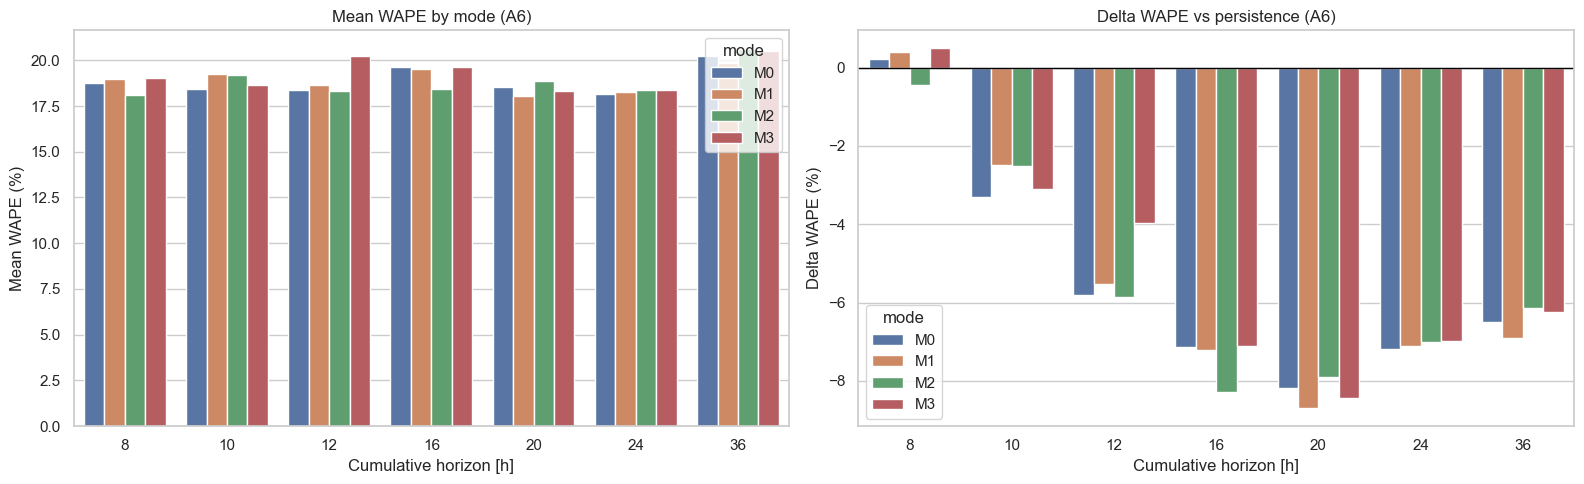

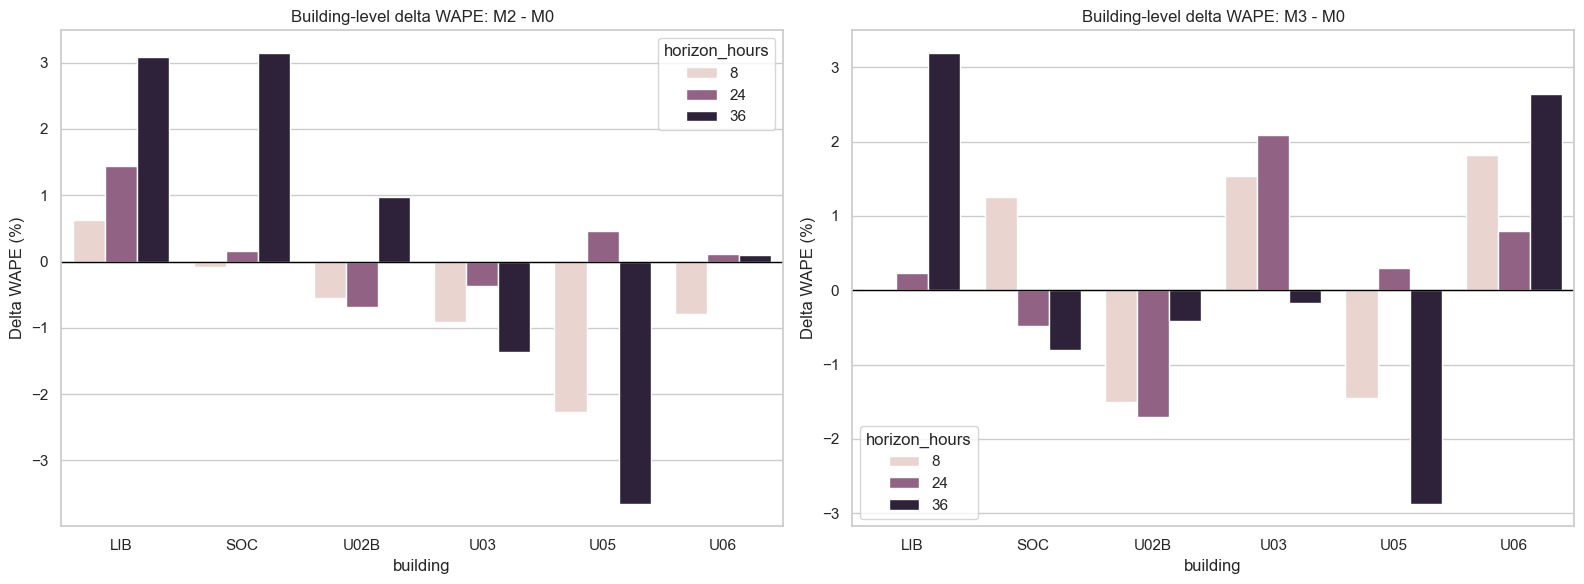

Saved:
- /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_run_log_21032026.csv
- /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_summary_21032026.csv
- /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_mode_overall_21032026.csv
- /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_gain_vs_M0_21032026.csv


In [6]:
# Section 5 - Summaries, gains, and quick plots

from scipy import stats


def mean_ci95(x: pd.Series) -> Tuple[float, float, float]:
    arr = pd.Series(x).dropna().astype(float).to_numpy()
    if len(arr) == 0:
        return np.nan, np.nan, np.nan
    mean = float(arr.mean())
    if len(arr) == 1:
        return mean, mean, mean
    lo, hi = stats.t.interval(0.95, len(arr) - 1, loc=mean, scale=stats.sem(arr))
    return mean, float(lo), float(hi)


if 'run_log_df' not in locals() or run_log_df.empty:
    print('No run log available yet.')
else:
    ok_df = run_log_df.loc[run_log_df['status'] == 'ok'].copy()

    summary_rows = []
    for keys, sub in ok_df.groupby(['target_family', 'target_name', 'horizon_hours', 'mode'], observed=True):
        target_family, target_name, horizon_hours, mode = keys
        w_mean, w_lo, w_hi = mean_ci95(sub['wape_pct'])
        b_mean, b_lo, b_hi = mean_ci95(sub['delta_wape_vs_baseline'])
        summary_rows.append({
            'target_family': target_family,
            'target_name': target_name,
            'horizon_hours': horizon_hours,
            'mode': mode,
            'selected_architecture_id': SELECTED_ARCHITECTURE_ID,
            'n_runs': len(sub),
            'wape_mean': w_mean,
            'wape_ci95_low': w_lo,
            'wape_ci95_high': w_hi,
            'delta_vs_baseline_mean': b_mean,
            'delta_vs_baseline_ci95_low': b_lo,
            'delta_vs_baseline_ci95_high': b_hi,
            'mae_mean': float(sub['mae'].mean()),
            'rmse_mean': float(sub['rmse'].mean()),
            'r2_mean': float(sub['r2'].mean()),
            'baseline_wape_mean': float(sub['baseline_wape_pct'].mean()),
        })
    summary_df = pd.DataFrame(summary_rows).sort_values(['target_family', 'horizon_hours', 'mode']).reset_index(drop=True)

    mode_overall_df = ok_df.groupby(['mode'], observed=True).agg(
        wape_mean=('wape_pct', 'mean'),
        wape_std=('wape_pct', 'std'),
        rmse_mean=('rmse', 'mean'),
        mae_mean=('mae', 'mean'),
        r2_mean=('r2', 'mean'),
        baseline_wape_mean=('baseline_wape_pct', 'mean'),
        delta_vs_baseline_mean=('delta_wape_vs_baseline', 'mean'),
        n_runs=('wape_pct', 'size'),
    ).reset_index().sort_values(['wape_mean', 'rmse_mean']).reset_index(drop=True)
    mode_overall_df['selected_architecture_id'] = SELECTED_ARCHITECTURE_ID
    mode_overall_df['selected_architecture_label'] = SELECTED_ARCHITECTURE['architecture_label']

    gain_rows = []
    for (building, target_name), sub in ok_df.groupby(['building', 'target_name'], observed=True):
        spec = next(s for s in TARGET_SPECS if s['target_name'] == target_name)
        piv = sub.groupby('mode', observed=True)['wape_pct'].mean().to_dict()
        base = float(sub['baseline_wape_pct'].mean())
        if 'M0' not in piv:
            continue
        gain_rows.append({
            'building': building,
            'target_name': target_name,
            'target_family': spec['target_family'],
            'horizon_hours': spec['horizon_hours'],
            'selected_architecture_id': SELECTED_ARCHITECTURE_ID,
            'baseline_wape_pct': base,
            'M0': piv.get('M0', np.nan),
            'M1': piv.get('M1', np.nan),
            'M2': piv.get('M2', np.nan),
            'M3': piv.get('M3', np.nan),
            'delta_wape_M1_minus_M0': piv.get('M1', np.nan) - piv.get('M0', np.nan),
            'delta_wape_M2_minus_M0': piv.get('M2', np.nan) - piv.get('M0', np.nan),
            'delta_wape_M3_minus_M0': piv.get('M3', np.nan) - piv.get('M0', np.nan),
            'delta_wape_M0_minus_baseline': piv.get('M0', np.nan) - base,
            'delta_wape_M2_minus_baseline': piv.get('M2', np.nan) - base,
            'delta_wape_M3_minus_baseline': piv.get('M3', np.nan) - base,
        })

    gain_df = pd.DataFrame(gain_rows)
    if not gain_df.empty:
        gain_df = gain_df.merge(
            proxy_df[['building_abv', 'vent_class', 'energy_class', 'ac24', 'night_day_ratio', 'n_vent_points']],
            left_on='building',
            right_on='building_abv',
            how='left',
        ).drop(columns=['building_abv'])

    summary_df.to_csv(SUMMARY_FILE, index=False)
    mode_overall_df.to_csv(MODE_OVERALL_FILE, index=False)
    gain_df.to_csv(GAIN_FILE, index=False)

    display(summary_df)
    display(mode_overall_df)
    if not gain_df.empty:
        display(gain_df.sort_values(['horizon_hours', 'building']).reset_index(drop=True))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
    sns.barplot(data=summary_df, x='horizon_hours', y='wape_mean', hue='mode', ax=axes[0], errorbar=None)
    axes[0].set_title(f'Mean WAPE by mode ({SELECTED_ARCHITECTURE_ID})')
    axes[0].set_xlabel('Cumulative horizon [h]')
    axes[0].set_ylabel('Mean WAPE (%)')

    sns.barplot(data=summary_df, x='horizon_hours', y='delta_vs_baseline_mean', hue='mode', ax=axes[1], errorbar=None)
    axes[1].axhline(0.0, color='black', linewidth=1)
    axes[1].set_title(f'Delta WAPE vs persistence ({SELECTED_ARCHITECTURE_ID})')
    axes[1].set_xlabel('Cumulative horizon [h]')
    axes[1].set_ylabel('Delta WAPE (%)')
    plt.tight_layout()
    plt.show()

    if not gain_df.empty:
        focus = gain_df[gain_df['horizon_hours'].isin([8, 24, 36])].copy()
        if not focus.empty:
            fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
            sns.barplot(data=focus, x='building', y='delta_wape_M2_minus_M0', hue='horizon_hours', ax=axes[0], errorbar=None)
            axes[0].axhline(0.0, color='black', linewidth=1)
            axes[0].set_title('Building-level delta WAPE: M2 - M0')
            axes[0].set_ylabel('Delta WAPE (%)')

            sns.barplot(data=focus, x='building', y='delta_wape_M3_minus_M0', hue='horizon_hours', ax=axes[1], errorbar=None)
            axes[1].axhline(0.0, color='black', linewidth=1)
            axes[1].set_title('Building-level delta WAPE: M3 - M0')
            axes[1].set_ylabel('Delta WAPE (%)')
            plt.tight_layout()
            plt.show()

    print('Saved:')
    print('-', RUNLOG_FILE)
    print('-', SUMMARY_FILE)
    print('-', MODE_OVERALL_FILE)
    print('-', GAIN_FILE)

## After the run

The key files to inspect are:

- [/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_run_log_21032026.csv](/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_run_log_21032026.csv)
- [/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_summary_21032026.csv](/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_summary_21032026.csv)
- [/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_mode_overall_21032026.csv](/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_mode_overall_21032026.csv)
- [/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_gain_vs_M0_21032026.csv](/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/direct_long_horizon_feature_sweep_gain_vs_M0_21032026.csv)

What to look for first:

- whether `M2` or `M3` actually improves over `M0` at `8h+`,
- whether `M1` remains basically neutral,
- and whether the gains are concentrated in a few buildings or broad across the portfolio.